# 🛰️ GoPilot: methane plumes from one sentence
## Arab Youth Space Hackathon 2026: Challenge 813 · Theme 06, Air Quality & Environmental Intelligence

**Ask GoPilot, in plain language, to check an oil and gas site for methane on a given date.** GoPilot finds the
Sentinel-2 scenes, runs **MethaneMapper**, our own methane model, cross-checks it with a spectral index, and
returns map layers. This notebook streams that work live and puts the layers on an interactive map.

| What judges look for | Where |
|---|---|
| Problem and intended user | §1 |
| Visible results or a demo | §5 to §7 (saved outputs: no need to run anything) |
| Methods, assumptions and limitations | §3, §8 |
| Data sources and licences | §9 |
| How to run or review it | §4, §10 |

> **Reviewing without running?** Every cell below is saved with its outputs, the streamed run and the map
> included. To run it yourself, see §4.

<a name="1"></a>
## 🎯 1. The problem, and who it is for

**Methane warms about 80 times more than CO₂ over 20 years**, and a small number of oil and gas point sources
emit a large share of it. Many of those sources are in the Arab region. Finding them still means campaigns,
aircraft or a specialist working through satellite data by hand, site by site.

**Sentinel-2 can see many of them for free**: global coverage every 5 days, with two SWIR bands where methane
absorbs. What has been missing is a model that reads that signal reliably, and a way for a non-specialist to use
it.

**Who uses this:**

- **Operators' LDAR and ESG teams**: find and fix leaks before they become a reporting problem.
- **Regulators and environment agencies**: screen many facilities without a field campaign.
- **MRV and carbon verifiers**: an independent, repeatable check on reported emissions.

With GoPilot the request is one sentence, and the answer is a map.

## 🛰️ 2. What GoPilot is: a product, not a demo

**GoPilot is RASID's geospatial AI agent.** You ask in plain language, and it plans the job, picks the data and
the models, runs them through our GoServer tool layer, and hands back an answer with map layers. No GIS
software, no code, no specialist.

- **In market today, on four surfaces:** the browser at [app.rasid.ai](https://app.rasid.ai), a native
  **ArcGIS Pro** add-in, a **QGIS** plugin, and an **MCP connector and API**. This notebook uses the API.
- **What it can reach:** 93 geospatial tools, 105+ AI models and 8,500+ datasets (optical, SAR, hyperspectral,
  DEM, land cover, climate, buildings, crops).
- **Users:** 100+ registered users and 10+ paying subscriptions.
- **Recognition:** winning team of the **AWS GenAI for Geospatial Challenge 2026** (EMEA).
- **Track record:** RASID has 11 years of Earth-observation delivery behind it, and GoPilot itself has been in
  development for the past six years.

**How a request flows:** this notebook → **GoPilot** (Claude on Amazon Bedrock AgentCore) → **GoServer** (MCP
tool servers on serverless GPUs) → our models, including MethaneMapper → results on S3, returned as map layers.

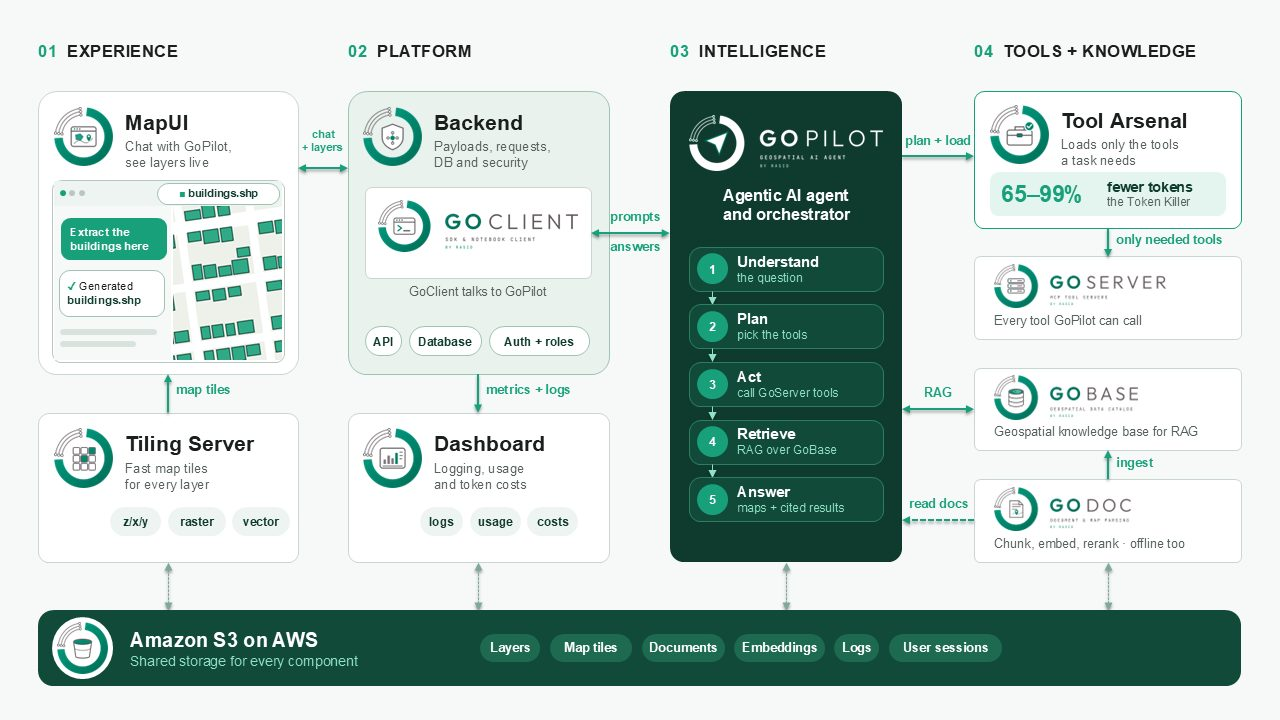

<a name="3"></a>
## 🧪 3. MethaneMapper, our methane model

**MethaneMapper is RASID's own model**, built over a six-month project. Its distinguishing choice: **it was
trained only on physically simulated plumes**, because real labelled methane plumes are too few, too uneven in
size and too biased toward famous sites to train on.

**The physics.** Methane absorbs strongly in Sentinel-2's B12 (~2190 nm) and only weakly in B11 (~1610 nm), so a
plume darkens B12 relative to B11. The fractional change of the band ratio between a target date and clean
reference dates is the signal:

$$\text{frac} = 1 - \frac{B12'/B11'}{B12/B11}, \qquad \text{frac} > 0 \Rightarrow \text{CH}_4$$

**The synthetic-data pipeline (TS2M-S):**

1. **Radiative transfer:** ESA spectral response functions + HITRAN → 57 lookup tables (3 satellites × 19 sun
   angles).
2. **Plume simulation:** Gaussian puff with turbulent wind → 25,000 plume shapes.
3. **Scene sampling:** real Sentinel-2 L1C target scenes plus references (T−90 ×2, T−365), 2021 to 2025.
4. **Plume insertion:** rescaled to 500–50,000 kg/h, rotated and placed on valid surfaces, in B11 and B12 only.
5. **Labels:** the synthetic image, the frac map, the plume mask, the source point and the exact flux.

**The model (CompUNet):** one shared ResNet-34 encoder reads the target and every reference scene. Reference
features are pooled per scale, joined with the target's, and decoded by a U-Net into a plume mask and a frac
map. It trains on a target and 2 references, and runs on any number of references.

**Result:** trained with no real plumes at all, **MethaneMapper recovers 75%+ of confirmed real Sentinel-2
plume events.** Detections in the region include Zarzaitine and Hassi Messaoud (Algeria), Turaif and central
Saudi Arabia, Block 9 (Oman) and GC-28 (Kuwait), from 200 kg/h to 35 t/h.

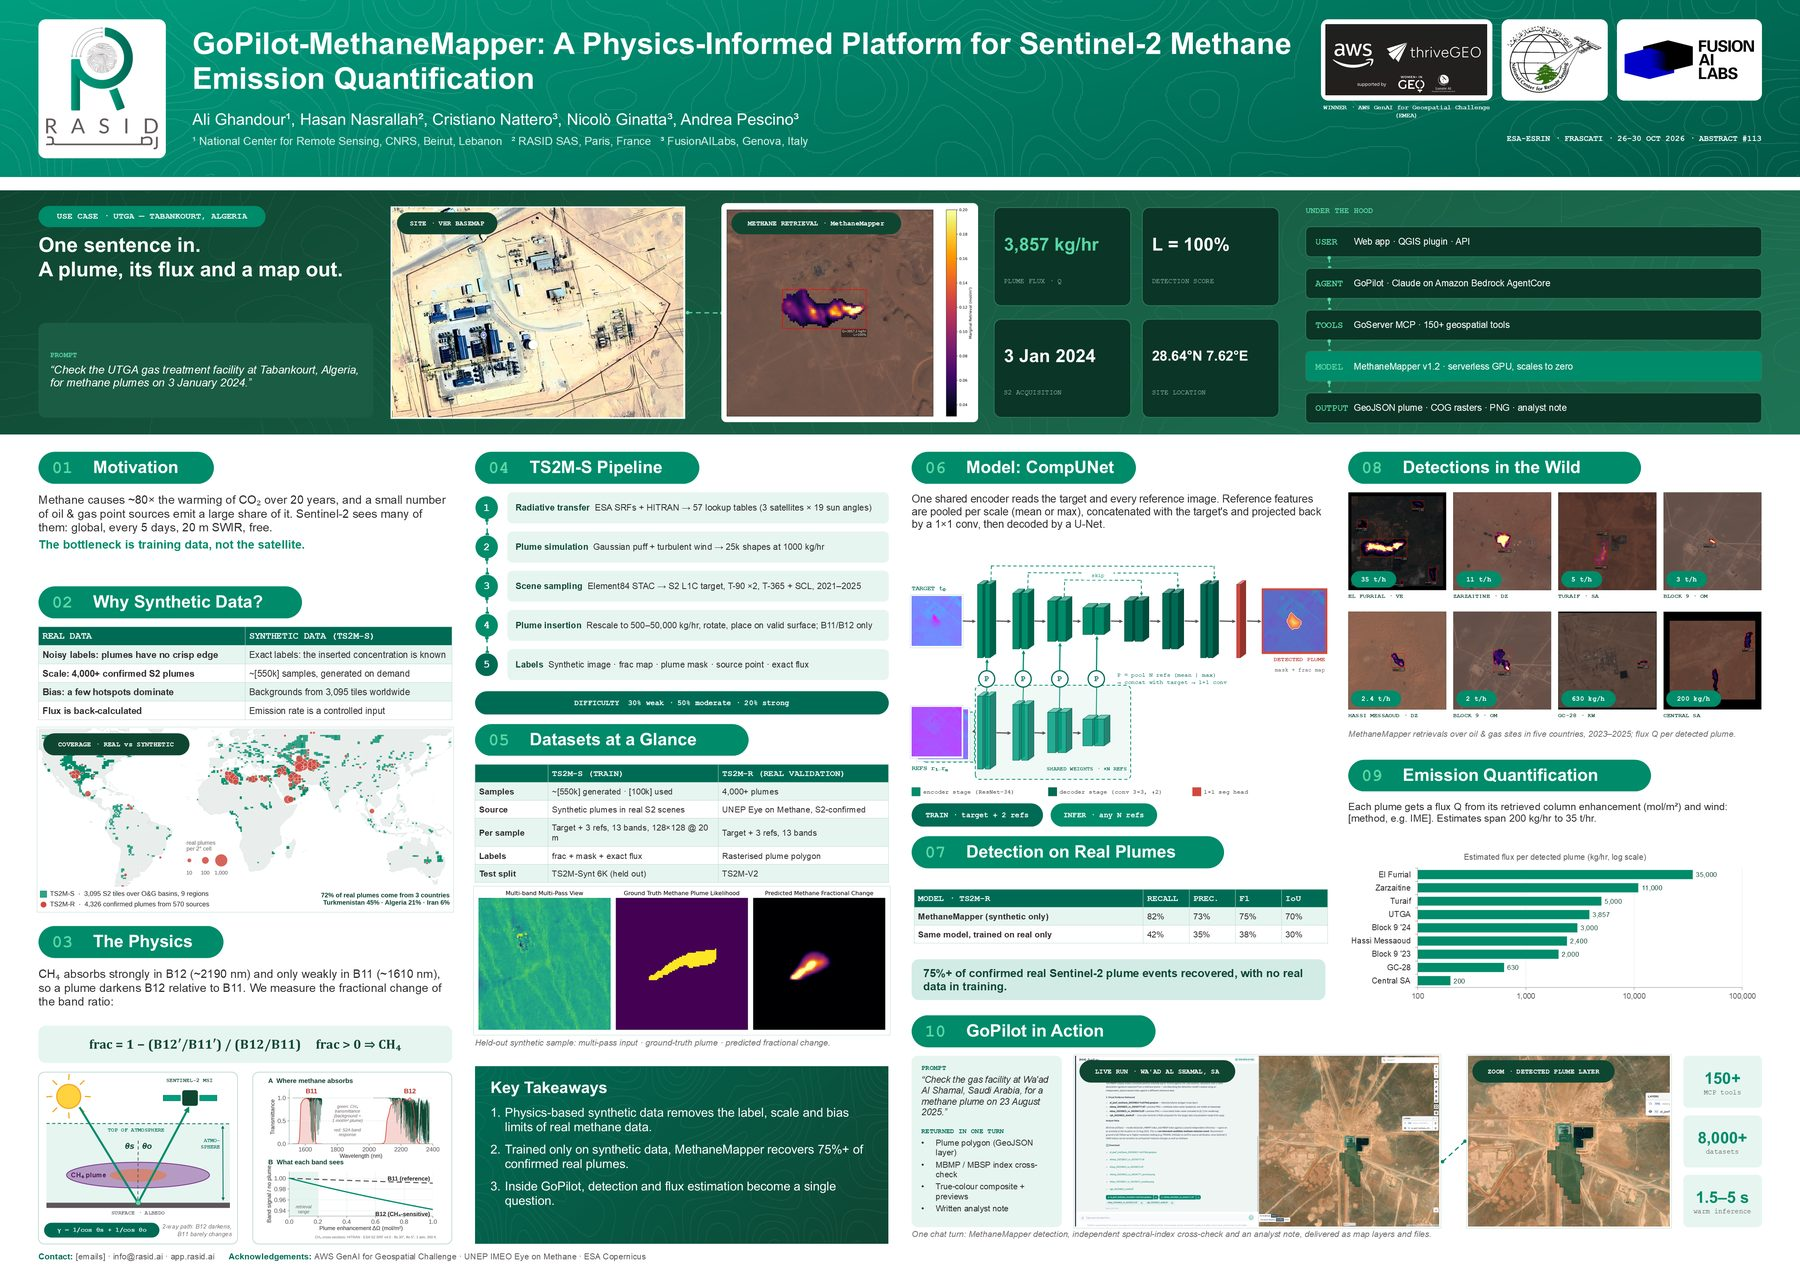

<sub>MethaneMapper: A. Ghandour (CNRS-L), H. Nasrallah (RASID), with C. Nattero, N. Ginatta and A. Pescino
(FusionAILabs). ESA-ESRIN, Frascati, Oct 2026, abstract #113.</sub>

<a name="4"></a>
## ⚙️ 4. Setup

**Reviewing only?** Skip to §5: the outputs are saved.

**Running it yourself** needs three values, which you get from us with the submission. **Never paste them into
a cell.** In Colab, open the 🔑 **Secrets** panel (left sidebar), add these three names, and turn on
*Notebook access* for each:

| Secret name | What it is |
|---|---|
| `AWS_ACCESS_KEY_ID` | Access key of the judge user (allowed only to call this one GoPilot runtime) |
| `AWS_SECRET_ACCESS_KEY` | Its secret key |
| `GOPILOT_AGENT_ARN` | The GoPilot runtime to call |

Outside Colab, set the same names as environment variables. If neither is found, the cell asks for them.

In [ ]:
%pip install -q boto3 rasterio folium markdown

In [2]:
import os
from getpass import getpass


def _secret(name, hidden=True):
    # Colab Secrets first, then the environment, then ask. Never hard-code these.
    try:
        from google.colab import userdata
        value = userdata.get(name)
        if value:
            return value
    except Exception:
        pass
    if os.environ.get(name):
        return os.environ[name]
    return (getpass if hidden else input)(f"{name}: ").strip()


AWS_ACCESS_KEY_ID = _secret("AWS_ACCESS_KEY_ID")
AWS_SECRET_ACCESS_KEY = _secret("AWS_SECRET_ACCESS_KEY")
GOPILOT_AGENT_ARN = _secret("GOPILOT_AGENT_ARN", hidden=False)
GOPILOT_REGION = os.environ.get("GOPILOT_REGION") or GOPILOT_AGENT_ARN.split(":")[3] or "eu-central-1"
print("Credentials loaded for runtime in", GOPILOT_REGION)

Credentials loaded for runtime in eu-central-1


### The client

A small client for the GoPilot API. It sends a request and renders GoPilot's stream **live** as it arrives:

- every tool GoPilot calls, ⏳ while it runs and ✅ when it is done;
- its reasoning, folded;
- its final answer.

It keeps every output file GoPilot returns, for the map in §6. Download links are never printed, so saved
outputs stay clean.

In [4]:
import html as _html
import json
import re
import time
import uuid

import boto3
import markdown as _markdown
from botocore.config import Config
from IPython.display import HTML, display

_TOOL = re.compile(r'<tool id="(\d+)" status="(\w+)">(.*?)</tool>', re.S)
_TOKENS = re.compile(r"<(input|output|cache_read|cache_write|total)_tokens>(\d+)</\1_tokens>")
_FINAL = re.compile(r"<final>(.*?)(?:</final>|$)", re.S)
_THINK = re.compile(r"<think(?:_final)?>(.*?)(?:</think(?:_final)?>|(?=<tool|<final>)|$)", re.S)
_META = re.compile(r"```file-meta\s*(\{.*?\})\s*```", re.S)
_LINK = re.compile(r"\[([^\]]+)\]\((https?://[^)\s]+)\)")
_GREEN, _DEEP, _MUTED = "#008A6E", "#0E3B2E", "#6B7570"


def _decode(line):
    # AgentCore sends each chunk as `data: <json string>` (or a {"t","d"} envelope).
    if not line.startswith("data: "):
        return line
    payload = line[6:]
    try:
        obj = json.loads(payload)
    except ValueError:
        return payload
    return obj["d"] if isinstance(obj, dict) and "d" in obj else obj


def _pretty_tool(name):
    return name.replace("_goserver", "").replace("_", " ")


class Run:
    """One GoPilot request: the raw stream, plus what the notebook reads out of it."""

    def __init__(self, prompt):
        self.prompt, self.raw, self.error = prompt, "", None
        self.t0, self.t1 = time.time(), None

    @property
    def done(self):
        return self.t1 is not None

    @property
    def elapsed(self):
        return (self.t1 or time.time()) - self.t0

    @property
    def tools(self):
        calls = {}
        for i, status, name in _TOOL.findall(self.raw):
            calls[int(i)] = (name.strip(), status)
        return [calls[i] for i in sorted(calls)]

    @property
    def tokens(self):
        return {k: int(v) for k, v in _TOKENS.findall(self.raw)}

    @property
    def final_md(self):
        m = _FINAL.search(self.raw)
        return m.group(1).strip() if m else ""

    @property
    def files(self):
        # {filename: download url}, from the download block at the end of the answer.
        return {name.strip(): url for name, url in _LINK.findall(self.final_md)}

    @property
    def file_meta(self):
        m = _META.search(self.raw)
        try:
            return json.loads(m.group(1)) if m else {}
        except ValueError:
            return {}

    @property
    def thinking(self):
        return "\n".join(t.strip() for t in _THINK.findall(self.raw) if t.strip())

    def to_html(self):
        status = ("❌ stopped" if self.error else "✅ done") if self.done else "⏳ working"
        tok = self.tokens.get("total")
        head = (f'<b style="color:{_DEEP}">GoPilot</b> · {status} · {self.elapsed:,.0f} s · '
                f'{len(self.tools)} tool calls' + (f" · {tok:,} tokens" if tok else ""))
        pills = "".join(
            f'<span style="display:inline-block;margin:2px 4px 2px 0;padding:2px 9px;border-radius:12px;'
            f'background:{"#E3F4EE" if s == "done" else "#FFF4D6"};color:{_DEEP};font-size:12px">'
            f'{"✅" if s == "done" else "⏳"} {_html.escape(_pretty_tool(n))}</span>' for n, s in self.tools)
        think = self.thinking
        think_html = ""
        if think:
            tail = think[-2500:]
            think_html = (f'<details style="margin:8px 0"><summary style="color:{_MUTED};cursor:pointer">'
                          f'🧠 GoPilot\'s reasoning ({len(think):,} characters)</summary>'
                          f'<div style="white-space:pre-wrap;font-size:12px;color:#3c4a44;max-height:260px;'
                          f'overflow:auto;background:#f6f9f8;padding:8px;border-radius:6px">'
                          f'{_html.escape(("…" if len(think) > 2500 else "") + tail)}</div></details>')
        answer = self.final_md
        if answer:
            # Download links become plain file names: saved outputs never carry a signed URL.
            answer = _LINK.sub(lambda m: f"`{m.group(1)}`", answer)
            answer = _markdown.markdown(answer, extensions=["tables", "fenced_code"])
        elif self.done and not self.error:
            answer = f'<i style="color:{_MUTED}">(no answer text)</i>'
        err = (f'<div style="color:#b3261e;margin-top:6px">{_html.escape(self.error)}</div>'
               if self.error else "")
        return (f'<div style="font-family:system-ui,sans-serif;border:1px solid #d6e5df;border-radius:10px;'
                f'padding:12px 14px;max-width:980px">'
                f'<div style="font-size:14px">{head}</div>'
                f'<div style="margin:8px 0;padding:8px 10px;background:#f2f7f5;border-left:3px solid {_GREEN};'
                f'border-radius:4px"><b>You:</b> {_html.escape(self.prompt)}</div>'
                f'<div>{pills}</div>{think_html}'
                f'<div style="margin-top:8px;font-size:14px;line-height:1.5">{answer}</div>{err}</div>')

    def _repr_html_(self):
        return self.to_html()


class GoPilotClient:
    """A minimal client for the GoPilot API (Amazon Bedrock AgentCore runtime)."""

    def __init__(self, agent_arn, region, aws_access_key_id=None, aws_secret_access_key=None,
                 user_id="aysh-813-review"):
        self.agent_arn, self.user_id = agent_arn, user_id
        self._runtime = boto3.client(
            "bedrock-agentcore", region_name=region,
            aws_access_key_id=aws_access_key_id, aws_secret_access_key=aws_secret_access_key,
            # Runs last minutes; no automatic retries, which would start the run twice.
            config=Config(read_timeout=900, connect_timeout=30, retries={"max_attempts": 0}))

    def ask(self, prompt, session_id=None, model_name=None, reasoning_effort=None, live=True):
        """Send one request and stream it into the notebook. Each call is a fresh session unless
        session_id is given (pass run.session_id to follow up on an earlier answer)."""
        run = Run(prompt)
        run.session_id = session_id or f"aysh813-{uuid.uuid4().hex}"      # AgentCore wants >= 33 chars
        payload = {"prompt": prompt, "session_id": run.session_id, "user_id": self.user_id,
                   "config_version": "v1.0"}
        if model_name:
            payload["model_name"] = model_name
        if reasoning_effort:
            payload["reasoning_effort"] = reasoning_effort
        handle = display(HTML(run.to_html()), display_id=True) if live else None
        last = 0.0
        try:
            response = self._runtime.invoke_agent_runtime(
                agentRuntimeArn=self.agent_arn, runtimeSessionId=run.session_id,
                runtimeUserId=self.user_id, payload=json.dumps(payload).encode())
            # Small chunks so the stream renders as it arrives, not in kilobyte lumps.
            for line in response["response"].iter_lines(chunk_size=32):
                if line:
                    run.raw += _decode(line.decode("utf-8"))
                    if handle and time.time() - last > 0.5:
                        handle.update(HTML(run.to_html()))
                        last = time.time()
        except Exception as e:                       # shown in the card instead of a traceback
            run.error = f"{type(e).__name__}: {e}"
        finally:
            run.t1 = time.time()
            if "Yowza Something Wrong Happened" in run.raw and not run.error:
                run.error = "GoPilot reported an internal error; run the cell again."
            if handle:
                handle.update(HTML(run.to_html()))
        return run


gopilot = GoPilotClient(GOPILOT_AGENT_ARN, GOPILOT_REGION, AWS_ACCESS_KEY_ID, AWS_SECRET_ACCESS_KEY)
print("GoPilot client ready.")

GoPilot client ready.


In [6]:
import base64
import io
import re
from xml.etree import ElementTree as ET

import folium
import numpy as np
import rasterio
import requests
from PIL import Image
from matplotlib import colormaps
from rasterio.warp import Resampling, calculate_default_transform, reproject, transform_bounds

ESRI = "https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}"
_RASTER_EXT = (".tif", ".tiff")
_VECTOR_EXT = (".geojson", ".json")


def _local(tag):
    return tag.rsplit("}", 1)[-1]


def _xml(sld):
    # Drop namespace declarations and prefixes, so a style parses whether or not it declares them.
    s = re.sub(r"<\?xml[^>]*\?>", "", sld)
    s = re.sub(r'\s[\w:]*(xmlns|schemaLocation)(:\w+)?="[^"]*"', "", s)
    return ET.fromstring(re.sub(r"(</?)[\w.-]+:", r"\1", s))


def _hex_rgb(c):
    c = c.lstrip("#")
    return tuple(int(c[i:i + 2], 16) for i in (0, 2, 4))


def _sld_colormap(sld):
    """Raster SLD -> (type, [(value, (r, g, b, a))]) or None."""
    try:
        root = _xml(sld)
    except ET.ParseError:
        return None
    for el in root.iter():
        if _local(el.tag) == "ColorMap":
            entries = []
            for e in el:
                if _local(e.tag) == "ColorMapEntry" and e.get("color"):
                    a = float(e.get("opacity", 1.0))
                    entries.append((float(e.get("quantity")), (*_hex_rgb(e.get("color")), int(255 * a))))
            if entries:
                return el.get("type", "ramp"), sorted(entries)
    return None


def _sld_vector(sld):
    """Vector SLD -> (column, {value: fill}, default fill, stroke)."""
    out = {"column": None, "classes": {}, "fill": None, "stroke": None}
    if not sld:
        return out
    try:
        root = _xml(sld)
    except ET.ParseError:
        return out
    for rule in (e for e in root.iter() if _local(e.tag) == "Rule"):
        params = {p.get("name"): (p.text or "").strip() for p in rule.iter() if _local(p.tag) in ("SvgParameter", "CssParameter")}
        prop = next((p.text for p in rule.iter() if _local(p.tag) == "PropertyName"), None)
        lit = next((p.text for p in rule.iter() if _local(p.tag) == "Literal"), None)
        if prop is not None and lit is not None and params.get("fill"):
            out["column"] = prop
            out["classes"][str(lit)] = params["fill"]
        elif params.get("fill"):
            out["fill"] = out["fill"] or params["fill"]
        out["stroke"] = out["stroke"] or params.get("stroke")
    return out


def _band_choice(src):
    names = [(d or "").upper() for d in src.descriptions]
    if all(b in names for b in ("B04", "B03", "B02")):
        return [names.index(b) + 1 for b in ("B04", "B03", "B02")]
    if src.count == 13:                     # full Sentinel-2 L1C stack, standard band order
        return [4, 3, 2]
    if src.count in (3, 4):
        return [1, 2, 3]
    return [1]


def _raster_overlay(data, meta, max_px=1024):
    """GeoTIFF bytes -> (PNG data url, [[south, west], [north, east]]), drawn like GoPilot draws it."""
    sld = (meta or {}).get("sld")
    cmap = _sld_colormap(sld) if sld else None
    with rasterio.MemoryFile(data) as mf, mf.open() as src:
        bands = [1] if cmap else _band_choice(src)
        dst = "EPSG:3857"                    # warp to the web map's projection, so pixels line up
        _, w, h = calculate_default_transform(src.crs, dst, src.width, src.height, *src.bounds)
        s = max(w, h) / max_px
        if s > 1:
            w, h = max(1, int(w / s)), max(1, int(h / s))
        transform, w, h = calculate_default_transform(src.crs, dst, src.width, src.height, *src.bounds,
                                                      dst_width=w, dst_height=h)
        arr = np.full((len(bands), h, w), np.nan, np.float32)
        for k, b in enumerate(bands):
            reproject(rasterio.band(src, b), arr[k], src_transform=src.transform, src_crs=src.crs,
                      src_nodata=src.nodata, dst_transform=transform, dst_crs=dst, dst_nodata=np.nan,
                      resampling=Resampling.nearest if cmap else Resampling.bilinear)
    left, top = transform.c, transform.f
    right, bottom = left + transform.a * w, top + transform.e * h
    west, south, east, north = transform_bounds(dst, "EPSG:4326", left, bottom, right, top)
    ok = np.all(np.isfinite(arr), 0)
    rgba = np.zeros((h, w, 4), np.uint8)
    if cmap:                                 # GoPilot's own colours
        kind, entries = cmap
        v = arr[0]
        qs = np.array([q for q, _ in entries])
        cols = np.array([c for _, c in entries], float)
        if kind == "values":
            idx = np.abs(v[..., None] - qs).argmin(-1)
            hit = ok & np.isclose(v, qs[idx])
            rgba[hit] = cols[idx[hit]].astype(np.uint8)
        elif kind == "intervals":
            idx = np.clip(np.searchsorted(qs, v, side="left"), 0, len(qs) - 1)
            rgba[ok] = cols[idx[ok]].astype(np.uint8)
        else:
            for c in range(4):
                rgba[..., c] = np.where(ok, np.interp(np.nan_to_num(v), qs, cols[:, c]), 0).astype(np.uint8)
    elif len(bands) == 3:                    # true colour, 2-98 % stretch
        ok &= np.any(arr > 0, 0)
        for c in range(3):
            lo, hi = np.nanpercentile(arr[c][ok], [2, 98]) if ok.any() else (0, 1)
            rgba[..., c] = (np.clip((arr[c] - lo) / max(hi - lo, 1e-9), 0, 1) * 255).astype(np.uint8)
        rgba[..., 3] = ok * 255
    else:                                    # a single band without a style
        v = arr[0]
        if ok.any():
            lo, hi = np.nanpercentile(v[ok], [2, 98])
            rgba[...] = (colormaps["magma"](np.clip((v - lo) / max(hi - lo, 1e-9), 0, 1)) * 255).astype(np.uint8)
        rgba[..., 3] = ok * 220
    # Photographic layers as WebP (a fraction of PNG's size, alpha kept); styled layers as lossless PNG.
    buf, fmt = io.BytesIO(), "WEBP" if (not cmap and len(bands) == 3) else "PNG"
    Image.fromarray(rgba, "RGBA").save(buf, fmt, **({"quality": 80, "method": 6} if fmt == "WEBP" else {"optimize": True}))
    return f"data:image/{fmt.lower()};base64," + base64.b64encode(buf.getvalue()).decode(), [[south, west], [north, east]]


def _geojson_layer(gj, name, meta):
    style = _sld_vector((meta or {}).get("sld"))
    default = style["fill"] or "#FF3B30"
    stroke = style["stroke"] or "#FFFFFF"

    def paint(feature):
        props = feature.get("properties") or {}
        fill = style["classes"].get(str(props.get(style["column"])), default) if style["column"] else default
        return {"fillColor": fill, "color": stroke, "weight": 1.5, "fillOpacity": 0.6}

    props = (gj.get("features") or [{}])[0].get("properties") or {}
    fields = [k for k, v in props.items() if not isinstance(v, (dict, list))][:8]
    tooltip = folium.GeoJsonTooltip(fields=fields) if fields else None
    return folium.GeoJson(gj, name=name, style_function=paint, tooltip=tooltip)


def _bbox_of(gj):
    xs, ys = [], []

    def walk(c):
        if isinstance(c, (list, tuple)) and c and isinstance(c[0], (int, float)):
            xs.append(c[0]); ys.append(c[1])
        elif isinstance(c, (list, tuple)):
            for x in c:
                walk(x)
    for f in gj.get("features", []):
        walk((f.get("geometry") or {}).get("coordinates", []))
    return [[min(ys), min(xs)], [max(ys), max(xs)]] if xs else None


def show_layers(run, max_px=1024):
    """Every map layer GoPilot returned, on one interactive map. Returns (map, summary rows)."""
    m = folium.Map(tiles=None, control_scale=True, zoom_start=12)
    folium.TileLayer(ESRI, attr="Esri, Maxar, Earthstar Geographics", name="Satellite (Esri)").add_to(m)
    folium.TileLayer("OpenStreetMap", name="OpenStreetMap", show=False).add_to(m)
    rows, extent = [], []
    rasters = [f for f in run.files if f.lower().endswith(_RASTER_EXT)]
    vectors = [f for f in run.files if f.lower().endswith(_VECTOR_EXT)]
    for name in rasters + vectors:                       # rasters first, so vectors draw on top
        meta = run.file_meta.get(name, {})
        try:
            data = requests.get(run.files[name], timeout=120).content
            if name.lower().endswith(_RASTER_EXT):
                url, bounds = _raster_overlay(data, meta, max_px)
                # Styled layers (an index, a class map) see-through over the imagery, as in GoPilot's MapUI.
                opacity = 0.7 if meta.get("sld") else 1.0
                folium.raster_layers.ImageOverlay(url, bounds=bounds, name=name, opacity=opacity).add_to(m)
                extent.append(bounds)
                rows.append((name, "raster", "drawn"))
            else:
                gj = json.loads(data)
                n = len(gj.get("features", [])) if isinstance(gj, dict) else 0
                if n:
                    _geojson_layer(gj, name, meta).add_to(m)
                    extent.append(_bbox_of(gj))
                rows.append((name, "vector", f"{n} feature(s)"))
        except Exception as e:
            rows.append((name, "?", f"not drawn: {type(e).__name__}"))
    for name in run.files:
        if name not in rasters + vectors:
            rows.append((name, "file", "download only"))
    extent = [e for e in extent if e]
    if extent:
        m.fit_bounds([[min(e[0][0] for e in extent), min(e[0][1] for e in extent)],
                      [max(e[1][0] for e in extent), max(e[1][1] for e in extent)]])
    folium.LayerControl(collapsed=False).add_to(m)
    return m, rows


def layer_table(rows):
    body = "".join(f"<tr><td><code>{_html.escape(a)}</code></td><td>{b}</td><td>{c}</td></tr>" for a, b, c in rows)
    return HTML('<table style="font-family:system-ui;font-size:13px"><tr><th align=left>Layer</th>'
                f'<th align=left>Type</th><th align=left>On the map</th></tr>{body}</table>')


def plume_summary(run):
    """The plume layer's features, as a table: one row per plume and its attributes."""
    import pandas as pd
    rows = []
    for name, url in run.files.items():
        if name.lower().endswith(_VECTOR_EXT) and "methane" in name.lower():
            gj = requests.get(url, timeout=120).json()
            for i, f in enumerate(gj.get("features", []), 1):
                rows.append({"layer": name, "plume": i, **{k: v for k, v in (f.get("properties") or {}).items()
                                                            if not isinstance(v, (dict, list))}})
    return pd.DataFrame(rows) if rows else "No methane plume layer in this run (or zero plumes detected)."


print("Map helpers ready.")

Map helpers ready.


<a name="5"></a>
## 🔥 5. Use case 1: check a gas facility for methane on a given date

One sentence, nothing else: no coordinates, no scene IDs, no band names. GoPilot geocodes the site, finds a clear
Sentinel-2 L1C scene for the date plus clean reference scenes, runs MethaneMapper, cross-checks it with a
spectral index, and writes a short analyst note.

The site, Wa'ad Al Shamal in Saudi Arabia, is one of the regional detections from our poster. A run takes a few
minutes; watch the tools tick off.

In [7]:
PROMPT = "Check the gas facility at Wa'ad Al Shamal, Saudi Arabia, for a methane plume on 23 August 2025."

methane_run = gopilot.ask(PROMPT)

Role,Scene ID,Date,Cloud Cover,AOI Coverage
Reference 1,S2C_37SDR_20250814_0_L1C,2025-08-14,0.00%,100%
Reference 2,S2A_37SDR_20250816_1_L1C,2025-08-16,0.01%,100%
Target,S2A_37SDR_20250823_0_L1C,2025-08-23,0.06%,100%


<a name="6"></a>
## 🗺️ 6. The results on an interactive map

Every layer GoPilot produced, drawn in GoPilot's own map styles. Toggle layers with the control at the top
right, and click a plume for its attributes. The layers are embedded in the map, so it still works in the saved
notebook after GoPilot's download links expire.

In [14]:
methane_map, methane_layers = show_layers(methane_run)
display(layer_table(methane_layers))
methane_map

Layer,Type,On the map
waad_alshamal_methane_20250823-ad9797aa.geojson,vector,20 feature(s)


In [ ]:
plume_summary(methane_run)

<a name="7"></a>
## 🔎 7. Reading the result

- **The plume polygons** are MethaneMapper's detection: where the B12/B11 ratio dropped on the target date
  compared with the reference dates, in a plume-shaped pattern the model learned from simulated plumes.
- **The spectral index layer** (MBMP / MBSP, if GoPilot produced it) is an independent check computed directly
  from the bands, with no model. Agreement between the two strengthens a detection.
- **Zero plumes is a valid answer**: it means MethaneMapper found nothing above its detection floor on that date.

<a name="8"></a>
## 📐 8. Methods, assumptions and limitations

**Method:**

1. GoPilot turns the request into a plan.
2. It fetches a Sentinel-2 L1C target scene for the date, plus clean reference scenes of the same area.
3. MethaneMapper compares the target against the references and segments plumes.
4. A band-ratio index (MBMP / MBSP) is computed for an independent cross-check.
5. Results are written as GeoJSON and Cloud-Optimised GeoTIFF layers.

**Assumptions and limitations:**

- **Detection floor.** Sentinel-2's 20 m SWIR sees large point sources: roughly hundreds of kg/h and up, depending
  on the surface and the sun. Small leaks are below it.
- **Surfaces.** Very bright, dark or wet surfaces and sharp edges can mimic or mask the B12/B11 signal. Clean
  reference scenes and the model's training reduce this, but do not remove it.
- **Clouds and timing.** A plume is only seen if the overpass is clear on the target date. Sentinel-2 revisits
  every ~5 days, so short events can be missed.
- **Reference scenes.** The result depends on the references being clean. GoPilot picks references with low cloud
  within about 90 days.
- **Flux.** Turning a plume into kg/h needs the wind at overpass time. When a run reports a flux, it is an
  estimate with that uncertainty.
- **L1C only.** The model was trained on top-of-atmosphere L1C, so it is not used on L2A.
- **An agent, not a fixed script.** Between runs GoPilot can choose different reference dates or extra checks.
  The run saved in this notebook is the one reviewed here.

<a name="9"></a>
## 📚 9. Data sources and licences

| Data | Used for | Licence |
|---|---|---|
| **Copernicus Sentinel-2 L1C** (ESA), via Element84 Earth Search / AWS Open Data | Target and reference scenes: the core input | Free, full and open. *Contains modified Copernicus Sentinel data.* |
| **Esri World Imagery** | Basemap in §6 | Esri terms of use, with attribution (shown on the map) |
| **MethaneMapper** and **GoPilot** | Detection, orchestration | RASID proprietary, used as a service through the GoPilot API |

No data is redistributed in this notebook beyond the derived layers GoPilot returns for this request.

## ➕ 11. More use cases (optional)

The same pattern, `ask → map`, works across GoPilot's tools. Each cell below is independent; run any of them.

### 11a. Is it a persistent emitter? (Theme 06)

One detection is a snapshot. Regulators act on **persistence**: does the same site emit on several dates?

In [ ]:
persist_run = gopilot.ask(
    "Check the gas facility at Wa'ad Al Shamal, Saudi Arabia, for methane plumes on four clear Sentinel-2 dates "
    "between June and October 2025, and tell me whether it looks like a persistent emitter.")
persist_map, persist_layers = show_layers(persist_run)
display(layer_table(persist_layers))
persist_map

### 11b. Counting date palms, Saudi Arabia (Theme 02, Precision Agriculture)

One of our own regional models: date-palm detection, calibrated for Saudi Arabia.

In [ ]:
palms_run = gopilot.ask("Detect and count the date palms in a farm area east of Al-Hofuf, Al-Ahsa oasis, Saudi Arabia.")
palms_map, palms_layers = show_layers(palms_run)
display(layer_table(palms_layers))
palms_map

### 11c. Delineating fields, Saudi Arabia (Theme 02, Precision Agriculture)

Another regional model: field boundaries from Sentinel-2, tuned for centre-pivot and desert agriculture.

In [ ]:
fields_run = gopilot.ask("Delineate the agricultural fields around Wadi Ad-Dawasir, Saudi Arabia, from a recent Sentinel-2 scene.")
fields_map, fields_layers = show_layers(fields_run)
display(layer_table(fields_layers))
fields_map

<a name="10"></a>
## ▶️ 10. How to run or review

- **Review:** read the saved outputs. §5 has the full streamed run, and §6 the map.
- **Run:** add the three secrets (§4), then *Runtime → Run all*. The methane run takes a few minutes.
- **Try your own site:** change `PROMPT` in §5. Name a facility and a date, e.g. *"Check the gas facility at
  Hassi Messaoud, Algeria, for methane on 12 March 2025."*
- **If a run stops:** run the cell again. Each run is independent. A *"data source stopped responding"* message
  means an upstream catalogue timed out.

**Team RASID** · [rasid.ai](https://www.rasid.ai) · [app.rasid.ai](https://app.rasid.ai) · info@rasid.ai